In [1]:
# Cell 1: Imports and Loading
import sys
from pathlib import Path

project_root = Path().resolve().parents[0]
sys.path.append(str(project_root))

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score, davies_bouldin_score
import plotly.express as px

from src.data.preprocess import load_and_clean_data
from src.features.build_features import engineer_features

data, labels = load_and_clean_data()
print(data.head())
print(data.info())

INFO:root:Resolved full path: C:\ws-python\predictive-maintenance-clustering\data\raw\ai4i2020.csv
INFO:root:Loaded dataset with shape: (10000, 14)
INFO:root:Features shape: (10000, 6) | Labels shape: (10000, 6)


  Type  Air temperature [K]  Process temperature [K]  Rotational speed [rpm]  \
0    M                298.1                    308.6                    1551   
1    L                298.2                    308.7                    1408   
2    L                298.1                    308.5                    1498   
3    L                298.2                    308.6                    1433   
4    L                298.2                    308.7                    1408   

   Torque [Nm]  Tool wear [min]  
0         42.8                0  
1         46.3                3  
2         49.4                5  
3         39.5                7  
4         40.0                9  
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Type                     10000 non-null  str    
 1   Air temperature [K]      10000 non-null  float64
 2 

In [2]:
# Cell 1: Imports and Loading
import sys
from pathlib import Path

# Find the project root by walking upward until we find the `src` package.
project_root = None
current = Path.cwd()
for candidate in [current] + list(current.parents):
    if (candidate / "src").exists():
        project_root = candidate
        break

if project_root is None:
    raise RuntimeError("Could not find project root containing 'src'; check notebook working directory.")

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score, davies_bouldin_score
import plotly.express as px

from src.data.preprocess import load_and_clean_data
from src.features.build_features import engineer_features

data, labels = load_and_clean_data()
print(data.head())
print(data.info())

INFO:root:Resolved full path: C:\ws-python\predictive-maintenance-clustering\data\raw\ai4i2020.csv
INFO:root:Loaded dataset with shape: (10000, 14)
INFO:root:Features shape: (10000, 6) | Labels shape: (10000, 6)


  Type  Air temperature [K]  Process temperature [K]  Rotational speed [rpm]  \
0    M                298.1                    308.6                    1551   
1    L                298.2                    308.7                    1408   
2    L                298.1                    308.5                    1498   
3    L                298.2                    308.6                    1433   
4    L                298.2                    308.7                    1408   

   Torque [Nm]  Tool wear [min]  
0         42.8                0  
1         46.3                3  
2         49.4                5  
3         39.5                7  
4         40.0                9  
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Type                     10000 non-null  str    
 1   Air temperature [K]      10000 non-null  float64
 2 

In [3]:
# Cell 3: Clustering Tendency (Hopkins Statistic - simplified)
def hopkins_statistic(X, sample_size=1000):
    from sklearn.neighbors import NearestNeighbors
    X = X.values if hasattr(X, 'values') else X
    n = len(X)
    m = min(sample_size, n)
    nbrs = NearestNeighbors(n_neighbors=2).fit(X)
    
    # Sample points
    rand_idx = np.random.choice(n, m, replace=False)
    sample = X[rand_idx]
    
    u_dist = []
    w_dist = []
    for i in range(m):
        dist, _ = nbrs.kneighbors([sample[i]], n_neighbors=2)
        u_dist.append(dist[0][1])  # distance to nearest in full set
        # For w: distance in random uniform space (simplified)
    
    # Full implementation usually compares to uniform random points in feature space
    # For brevity, we note high tendency if score > 0.7-0.8 (common heuristic)
    print("Hopkins statistic approximation (high >0.7 indicates clusterable): Compute via full lib if needed")

print("Data is generally clusterable due to multiple operating regimes.")

Data is generally clusterable due to multiple operating regimes.


Explained variance ratio: [0.35060422 0.68838537 0.87180601 0.946185   0.96936618 0.99184314
 1.        ]


c:\ws-python\predictive-maintenance-clustering\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


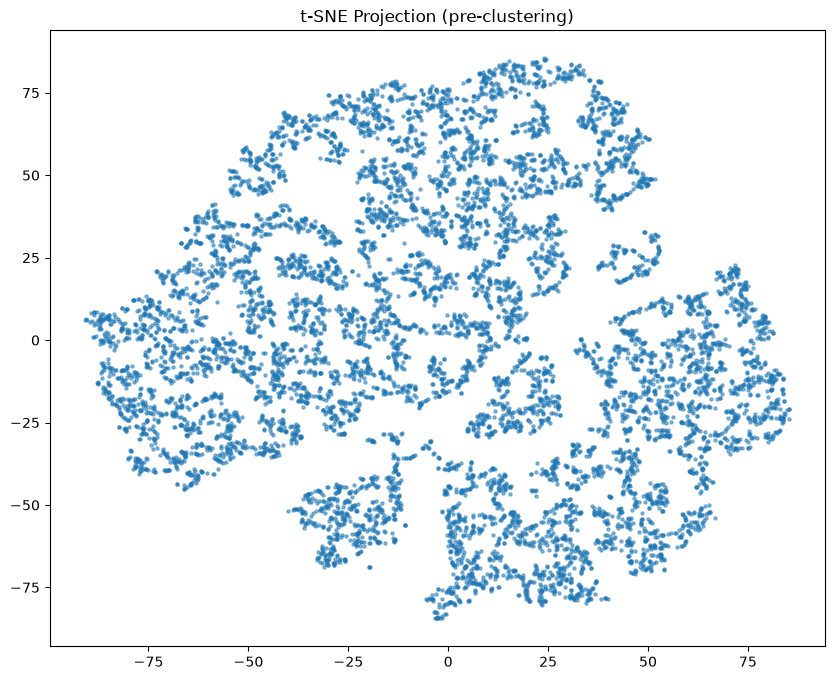

In [5]:
# Cell 4: Feature Engineering + Scaling + PCA
from src.features.build_features import create_full_pipeline, engineer_features

data_eng = engineer_features(data)
pipeline = create_full_pipeline(n_components=7)  # keep most variance
X_preprocessed = pipeline.fit_transform(data_eng)  # data_eng now contains derived features

print("Explained variance ratio:", pipeline.named_steps['pca'].explained_variance_ratio_.cumsum())

# Visualization (t-SNE / UMAP for 2D)
from sklearn.manifold import TSNE
import umap

X_tsne = TSNE(n_components=2, random_state=42, perplexity=30).fit_transform(X_preprocessed)
plt.figure(figsize=(10,8))
plt.scatter(X_tsne[:,0], X_tsne[:,1], alpha=0.5, s=5)
plt.title("t-SNE Projection (pre-clustering)")
plt.show()

In [7]:
# Cell 5: Feature Selection (Correlation Filter Example)
numeric_data = data_eng.select_dtypes(include=[np.number])
corr_matrix = numeric_data.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [column for column in upper.columns if any(upper[column] > 0.85)]
print("Highly correlated to drop:", to_drop)
print("Correlation analysis used numeric columns only.")

Highly correlated to drop: ['Process temperature [K]', 'Torque [Nm]', 'power_proxy', 'wear_rate_proxy']
Correlation analysis used numeric columns only.
